# Evaluation of a Personalized Search Engine

This notebook evaluates a personalized search engine using multiple persona-specific result files.

For each persona, the ranked results are divided into systems:

- **Baseline**: no explicit persona profile
- **No clicks**: persona profile exposed, but no click history
- **After clicks**: persona profile and accumulated click feedback

Each query contributes 30 rows:

- 10 rows for **Baseline**
- 10 rows for **No clicks**
- 10 rows for **After clicks**

The notebook computes ranking quality using **Precision@10** and **nDCG@10**, first per query and then averaged per persona.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path



##

In [16]:

PERSONAS_FOLDER = Path("Personas")

TOP_K = 10
RELEVANCE_THRESHOLD = 1   
SYSTEM_ORDER = ["Baseline", "No clicks", "After clicks"]
ROWS_PER_QUERY = 30
ROWS_PER_SYSTEM = 10

## Evaluation Metrics

Two standard Information Retrieval metrics are used.

### Precision@10

Precision@10 measures how many of the top 10 returned documents are relevant.

In this project, a document is treated as relevant when:

$$
\text{Relevance} \ge 1
$$

Thus,

$$
P@10 = \frac{\#\{\text{relevant documents in top 10}\}}{10}
$$

### nDCG@10

nDCG@10 is a graded relevance metric. It rewards not only retrieving relevant documents, but also ranking highly relevant ones earlier.

First, the Discounted Cumulative Gain is computed as:

$$
DCG@10 = \sum_{i=1}^{10} \frac{2^{rel_i} - 1}{\log_2(i+1)}
$$

where $rel_i$ is the relevance of the document at rank $i$.

Then the score is normalized by the ideal ranking:

$$
nDCG@10 = \frac{DCG@10}{IDCG@10}
$$

where $IDCG@10$ is the DCG of the same documents sorted by decreasing relevance.

In [17]:
def precision_at_k(relevances, k=10, threshold=1):
    """
    Precision@k using binary relevance.
    A document is considered relevant if relevance >= threshold.
    """
    rel = np.array(relevances[:k])
    return np.mean(rel >= threshold)


def dcg_at_k(relevances, k=10):
    """
    Standard graded DCG@k:
        DCG@k = sum((2^rel_i - 1) / log2(i + 1)), i starts at 1
    """
    rel = np.array(relevances[:k], dtype=float)
    positions = np.arange(1, len(rel) + 1)
    return np.sum((2**rel - 1) / np.log2(positions + 1))


def ndcg_at_k(relevances, k=10):
    """
    nDCG@k = DCG@k / IDCG@k
    where IDCG is the DCG of the ideal ranking.
    """
    actual = np.array(relevances[:k], dtype=float)
    ideal = np.sort(actual)[::-1]

    dcg = dcg_at_k(actual, k)
    idcg = dcg_at_k(ideal, k)

    if idcg == 0:
        return 0.0
    return dcg / idcg

## File name helper 

In [18]:
def persona_sort_key(path_obj):
    """
    Sort files like:
    Persona1.csv, Persona2.csv, ..., Persona10.csv
    """
    name = path_obj.stem  # e.g. "Persona12"
    digits = "".join(ch for ch in name if ch.isdigit())
    return int(digits) if digits else float("inf")

## Read the CSV- files and clean them

In [19]:
def load_persona_csv(file_path):
    """
    Load one persona CSV and clean its columns.

    Assumptions:
    - No Query_ID is needed
    - Every 30 rows = one query block
    - Each 30-row block contains:
        10 Baseline rows
        10 No clicks rows
        10 After clicks rows
    """
    df = pd.read_csv(file_path, sep=None, engine="python")

    df.columns = [
        str(c).strip().replace("\ufeff", "").lstrip(":")
        for c in df.columns
    ]

    unnamed_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    required_cols = {"System", "rank", "doc_id", "title", "Relevance"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{file_path.name}: missing required columns {missing}")

    df["System"] = df["System"].astype(str).str.strip()
    df["rank"] = pd.to_numeric(df["rank"], errors="raise")
    df["Relevance"] = pd.to_numeric(df["Relevance"], errors="raise")

    df = df.reset_index(drop=True)

    if len(df) % ROWS_PER_QUERY != 0:
        raise ValueError(
            f"{file_path.name}: expected number of rows divisible by {ROWS_PER_QUERY}, got {len(df)}"
        )

    df["Query"] = (df.index // ROWS_PER_QUERY) + 1

    return df

## Evaluate 

In [20]:
def evaluate_one_persona(df, k=10, threshold=1):
    """
    Compute metrics for one persona DataFrame.

    Returns:
    - per_query_df: one row per (Query, System)
    - summary_df: one row per System, averaged over that persona's queries
    """
    results = []

    for query_id in sorted(df["Query"].unique()):
        qdf = df[df["Query"] == query_id]

        for system in SYSTEM_ORDER:
            sdf = qdf[qdf["System"] == system].sort_values("rank")
            relevances = sdf["Relevance"].tolist()

            if len(relevances) != k:
                raise ValueError(
                    f"Query {query_id}, system '{system}' has {len(relevances)} rows instead of {k}"
                )

            p10 = precision_at_k(relevances, k=k, threshold=threshold)
            ndcg10 = ndcg_at_k(relevances, k=k)

            results.append({
                "Query": query_id,
                "System": system,
                "P@10": p10,
                "nDCG@10": ndcg10
            })

    per_query_df = pd.DataFrame(results)

    # Preserve system order
    per_query_df["System"] = pd.Categorical(
        per_query_df["System"],
        categories=SYSTEM_ORDER,
        ordered=True
    )
    per_query_df = per_query_df.sort_values(["Query", "System"]).reset_index(drop=True)

    summary_df = (
        per_query_df.groupby("System", as_index=False)[["P@10", "nDCG@10"]]
        .mean()
    )

    summary_df["System"] = pd.Categorical(
        summary_df["System"],
        categories=SYSTEM_ORDER,
        ordered=True
    )
    summary_df = summary_df.sort_values("System").reset_index(drop=True)

    return per_query_df, summary_df

### Just a helper function to extract the persona name from the csv file

In [21]:
def persona_name_from_file(file_path):
    """
    Example:
    Personas/Persona7.csv -> Persona7
    """
    return file_path.stem

In [22]:
persona_files = sorted(PERSONAS_FOLDER.glob("*.csv"), key=persona_sort_key)

print(f"Found {len(persona_files)} CSV files:")
for f in persona_files:
    print("-", f.name)

Found 12 CSV files:
- Persona1.csv
- Persona2.csv
- Persona3.csv
- Persona4.csv
- Persona5.csv
- Persona6.csv
- Persona7.csv
- Persona8.csv
- Persona9.csv
- Persona10.csv
- Person11.csv
- Persona12.csv


## Run evaluation on all csv files i.e on all personas

In [23]:
all_per_query = []
all_summary = []

for file_path in persona_files:
   

    df = load_persona_csv(file_path)

    per_query_df, summary_df = evaluate_one_persona(
        df,
        k=TOP_K,
        threshold=RELEVANCE_THRESHOLD
    )

    persona_name = persona_name_from_file(file_path)

    per_query_df.insert(0, "Persona", persona_name)
    summary_df.insert(0, "Persona", persona_name)

    all_per_query.append(per_query_df)
    all_summary.append(summary_df)

all_per_query_df = pd.concat(all_per_query, ignore_index=True)
all_summary_df = pd.concat(all_summary, ignore_index=True)

print("\nAll persona files processed successfully.")


All persona files processed successfully.


### LOOk at the combined tables

In [24]:
print("=== Combined per-query metrics ===")
display(all_per_query_df)

print("=== Combined persona-level averages ===")
display(all_summary_df)

=== Combined per-query metrics ===


,Persona,Query,System,P@10,nDCG@10
0,Persona1,1,Baseline,0.4,0.465362
1,Persona1,1,No clicks,0.4,0.613507
2,Persona1,1,After clicks,0.5,0.486576
3,Persona1,2,Baseline,0.8,0.566644
4,Persona1,2,No clicks,0.8,0.514778
...,...,...,...,...,...
67,Persona12,1,No clicks,0.8,0.605303
68,Persona12,1,After clicks,0.9,0.650374
69,Persona12,2,Baseline,0.7,0.734707
70,Persona12,2,No clicks,0.8,0.603177


=== Combined persona-level averages ===


,Persona,System,P@10,nDCG@10
0,Persona1,Baseline,0.60,0.516003
1,Persona1,No clicks,0.60,0.564143
2,Persona1,After clicks,0.60,0.490101
3,Persona2,Baseline,0.65,0.706397
4,Persona2,No clicks,0.75,0.802581
5,Persona2,After clicks,0.85,0.887531
6,Persona3,Baseline,0.70,0.763140
7,Persona3,No clicks,0.75,0.812738
8,Persona3,After clicks,0.75,0.831398
9,Persona4,Baseline,0.60,0.588577


## Show per persona

In [25]:
for persona in all_per_query_df["Persona"].unique():
    print("=" * 70)
    print(persona)
    print("=" * 70)

    print("\nPer-query metrics:")
    display(
        all_per_query_df[all_per_query_df["Persona"] == persona]
        .reset_index(drop=True)
    )

    print("Average across queries:")
    display(
        all_summary_df[all_summary_df["Persona"] == persona]
        .reset_index(drop=True)
    )

Persona1

Per-query metrics:


,Persona,Query,System,P@10,nDCG@10
0,Persona1,1,Baseline,0.4,0.465362
1,Persona1,1,No clicks,0.4,0.613507
2,Persona1,1,After clicks,0.5,0.486576
3,Persona1,2,Baseline,0.8,0.566644
4,Persona1,2,No clicks,0.8,0.514778
5,Persona1,2,After clicks,0.7,0.493627


Average across queries:


,Persona,System,P@10,nDCG@10
0,Persona1,Baseline,0.6,0.516003
1,Persona1,No clicks,0.6,0.564143
2,Persona1,After clicks,0.6,0.490101


Persona2

Per-query metrics:


...

,Persona,System,P@10,nDCG@10
0,Person11,Baseline,0.55,0.573508
1,Person11,No clicks,0.75,0.616488
2,Person11,After clicks,0.80,0.713269


Persona12

Per-query metrics:


,Persona,Query,System,P@10,nDCG@10
0,Persona12,1,Baseline,0.7,0.608984
1,Persona12,1,No clicks,0.8,0.605303
2,Persona12,1,After clicks,0.9,0.650374
3,Persona12,2,Baseline,0.7,0.734707
4,Persona12,2,No clicks,0.8,0.603177
5,Persona12,2,After clicks,0.8,0.660341


Average across queries:


,Persona,System,P@10,nDCG@10
0,Persona12,Baseline,0.70,0.671845
1,Persona12,No clicks,0.80,0.604240
2,Persona12,After clicks,0.85,0.655358


In [26]:
p10_pivot = all_summary_df.pivot(index="Persona", columns="System", values="P@10")
ndcg_pivot = all_summary_df.pivot(index="Persona", columns="System", values="nDCG@10")

p10_pivot = p10_pivot[SYSTEM_ORDER]
ndcg_pivot = ndcg_pivot[SYSTEM_ORDER]

p10_pivot = p10_pivot.reindex(sorted(p10_pivot.index, key=lambda x: int("".join(filter(str.isdigit, x)))))
ndcg_pivot = ndcg_pivot.reindex(sorted(ndcg_pivot.index, key=lambda x: int("".join(filter(str.isdigit, x)))))

display(p10_pivot)
display(ndcg_pivot)

System,Baseline,No clicks,After clicks
Persona,,,
Persona1,0.60,0.60,0.60
Persona2,0.65,0.75,0.85
Persona3,0.70,0.75,0.75
Persona4,0.60,0.60,0.65
Persona5,0.50,0.60,0.60
Persona6,0.60,0.70,0.80
Persona7,0.55,0.60,0.60
Persona8,0.85,0.80,0.90
Persona9,0.60,0.70,0.75


System,Baseline,No clicks,After clicks
Persona,,,
Persona1,0.516003,0.564143,0.490101
Persona2,0.706397,0.802581,0.887531
Persona3,0.763140,0.812738,0.831398
Persona4,0.588577,0.646713,0.703178
Persona5,0.606041,0.589112,0.595668
Persona6,0.753406,0.936874,0.915784
Persona7,0.633160,0.681352,0.711788
Persona8,0.649471,0.898557,0.843702
Persona9,0.582548,0.651051,0.742180


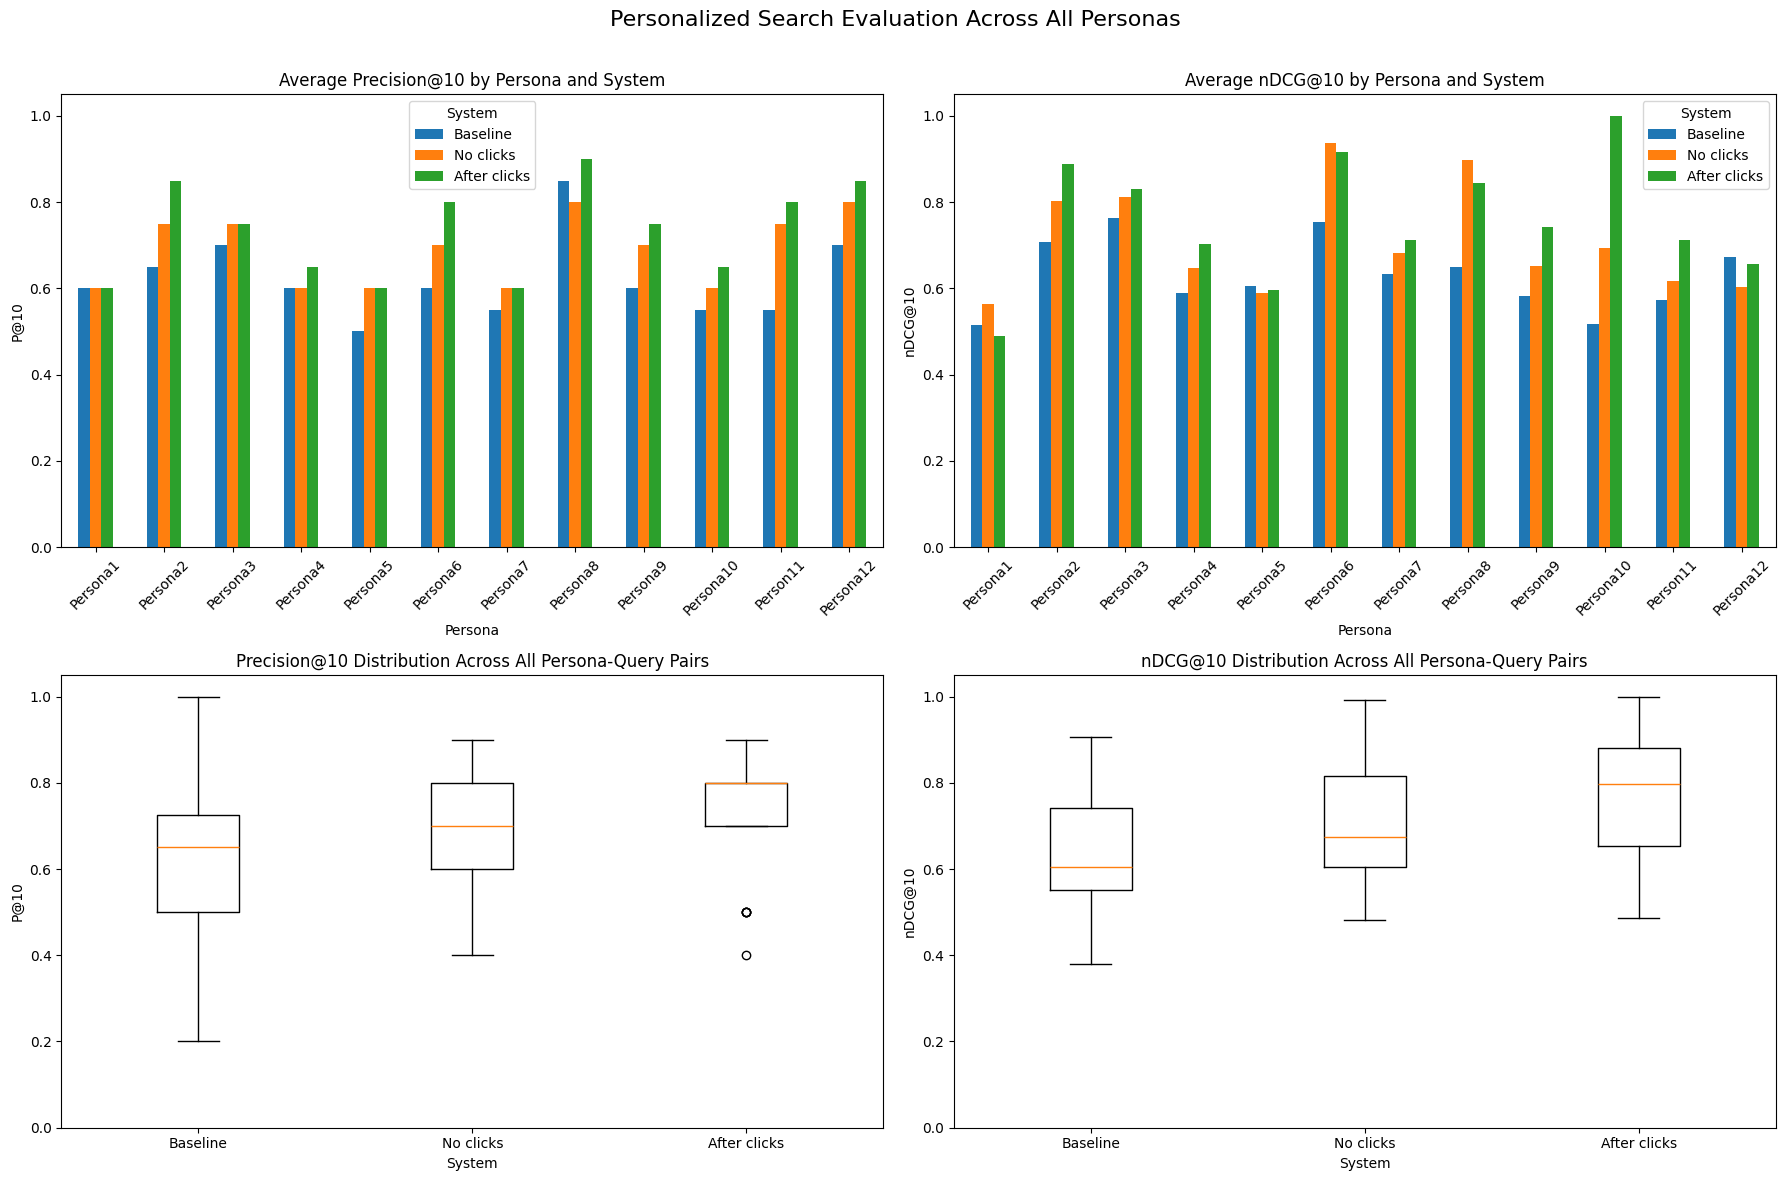

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -----------------------------
# Top-left: Average P@10 by persona
# -----------------------------
p10_pivot.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Average Precision@10 by Persona and System")
axes[0, 0].set_xlabel("Persona")
axes[0, 0].set_ylabel("P@10")
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend(title="System")

# -----------------------------
# Top-right: Average nDCG@10 by persona
# -----------------------------
ndcg_pivot.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Average nDCG@10 by Persona and System")
axes[0, 1].set_xlabel("Persona")
axes[0, 1].set_ylabel("nDCG@10")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend(title="System")

# -----------------------------
# Bottom-left: P@10 distribution over all persona-query pairs
# -----------------------------
p10_data = [
    all_per_query_df.loc[all_per_query_df["System"] == system, "P@10"].values
    for system in SYSTEM_ORDER
]

axes[1, 0].boxplot(p10_data, tick_labels=SYSTEM_ORDER)
axes[1, 0].set_title("Precision@10 Distribution Across All Persona-Query Pairs")
axes[1, 0].set_xlabel("System")
axes[1, 0].set_ylabel("P@10")
axes[1, 0].set_ylim(0, 1.05)

# -----------------------------
# Bottom-right: nDCG@10 distribution over all persona-query pairs
# -----------------------------
ndcg_data = [
    all_per_query_df.loc[all_per_query_df["System"] == system, "nDCG@10"].values
    for system in SYSTEM_ORDER
]

axes[1, 1].boxplot(ndcg_data, tick_labels=SYSTEM_ORDER)
axes[1, 1].set_title("nDCG@10 Distribution Across All Persona-Query Pairs")
axes[1, 1].set_xlabel("System")
axes[1, 1].set_ylabel("nDCG@10")
axes[1, 1].set_ylim(0, 1.05)

plt.suptitle("Personalized Search Evaluation Across All Personas", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Interpretation of the above plot

The evaluation shows that personalization is effective. Both Precision@10 and nDCG@10 improve substantially when the system uses persona information instead of the non-personalized baseline. In most cases, incorporating click history leads to further gains, particularly for Precision@10, showing that behavioral feedback helps refine the ranking. However, the nDCG@10 results also show that click-based personalization is not uniformly superior for every persona, suggesting that click signals may sometimes be noisy or limited. Overall, the results support the claim that the proposed personalized search approach improves ranking quality, with the strongest and most consistent gains coming from combining explicit persona information with interaction data.

In [28]:
overall_means = (
    all_per_query_df
    .groupby("System", as_index=False)[["P@10", "nDCG@10"]]
    .mean()
)

overall_means["System"] = pd.Categorical(
    overall_means["System"],
    categories=SYSTEM_ORDER,
    ordered=True
)
overall_means = overall_means.sort_values("System").reset_index(drop=True)

print("=== Overall mean metrics across all persona-query pairs ===")
display(overall_means)

=== Overall mean metrics across all persona-query pairs ===


,System,P@10,nDCG@10
0,Baseline,0.620833,0.630129
1,No clicks,0.687500,0.708136
2,After clicks,0.733333,0.757496


### Conclusion